In [17]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

from src.logger import setup_logging, get_logger
from src.db import load_missions_with_meta, health_check
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



In [18]:
setup_logging()
log = get_logger(__name__)

health_check()


01:39:21  INFO      ── Database Health Check ─────────────────────
01:39:21  INFO        dim_date                   12,081 rows
01:39:21  INFO        dim_agency                     27 rows
01:39:21  INFO        dim_launch                    139 rows
01:39:21  INFO        dim_mission_meta           10,500 rows
01:39:21  INFO        fact_missions              10,500 rows
01:39:21  INFO        bridge_crew                11,789 rows
01:39:21  INFO        bridge_partners             4,336 rows
01:39:21  INFO      Health check passed — all tables populated.
01:39:21  INFO      ──────────────────────────────────────────────


In [19]:
df = load_missions_with_meta()
df.shape

01:39:22  INFO      load_missions_with_meta → 10,500 rows


(10500, 30)

In [21]:
df.head()

,mission_id,mission_name,program_type,mission_category,sub_category,destination,status,mission_phase,crew_type,data_returned,...,launch_decade,end_date,end_year,end_quarter,end_month,end_decade,objective,key_achievement,mission_outcome_detail,reference_url
0,SP-10332,SpaceX Asteroid Mission 10332,Sounding Rocket,Asteroid,Impactor,Asteroid,Success,Past,Uncrewed,Partial,...,1950s,1964-07-07,1964.0,3.0,7.0,1960s,Orbital mechanics experiment for future missions,Achieved supersonic retropropulsion,Achieved orbit insertion on first attempt,https://www.spacex.com/missions/spacex-asteroi...
1,CN-09787,CNES Sounding Rocket Mission 9787,Satellite,Sounding Rocket,Atmospheric Study,Sounding Rocket,Partial Success,Past,Crewed,No,...,1950s,1958-09-04,1958.0,3.0,9.0,1950s,Space debris monitoring and removal,First images returned from target destination,Captured highest resolution images to date,https://cnes.fr/mission/cnes-sounding-rocket-m...
2,JA-03767,JAXA Mars Mission 3767,Robotic,Mars,Sample Return,Mars,Success,Past,Crewed,Partial,...,1950s,1957-05-12,1957.0,2.0,5.0,1950s,Black hole imaging and stellar cataloguing,Partial success - secondary objectives met,Collected and returned surface samples,https://www.jaxa.jp/missions/jaxa-mars-mission...
3,ES-09538,ESA Technology Demo Mission 9538,Human Spaceflight,Technology Demo,Propulsion Test,Technology Demo,Partial Success,Past,Uncrewed,Partial,...,1950s,1958-02-17,1958.0,1.0,2.0,1950s,Solar wind and coronal mass ejection monitoring,Landed successfully within target zone,Broke distance record for agency,https://www.esa.int/Science_Exploration/esa-te...
4,CN-10042,CNSA Technology Demo Mission 10042,Telescope,Technology Demo,In-Orbit Servicing,Technology Demo,Success,Past,Crewed,Partial,...,1950s,1962-11-02,1962.0,4.0,11.0,1960s,Lunar surface exploration and soil sample coll...,Collected and returned surface samples,Discovered new geological features,http://www.cnsa.gov.cn/mission/cnsa-technology...


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10500 entries, 0 to 10499
Data columns (total 30 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   mission_id              10500 non-null  object 
 1   mission_name            10500 non-null  object 
 2   program_type            10500 non-null  object 
 3   mission_category        10500 non-null  object 
 4   sub_category            10500 non-null  object 
 5   destination             10500 non-null  object 
 6   status                  10500 non-null  object 
 7   mission_phase           10500 non-null  object 
 8   crew_type               10500 non-null  object 
 9   data_returned           8940 non-null   object 
 10  failure_reason          1161 non-null   object 
 11  cost_usd_million        10500 non-null  object 
 12  duration_days           5561 non-null   object 
 13  agency_name             10500 non-null  object 
 14  country_region          10500 non-null

In [25]:
df.describe(include='all')

,mission_id,mission_name,program_type,mission_category,sub_category,destination,status,mission_phase,crew_type,data_returned,...,launch_decade,end_date,end_year,end_quarter,end_month,end_decade,objective,key_achievement,mission_outcome_detail,reference_url
count,10500,10500,10500,10500,10500,10500,10500,10500,10500,8940,...,10500,5796,5796.000000,5796.000000,5796.000000,5796,10500,10179,10500,10500
unique,10500,10477,7,19,66,19,5,3,2,3,...,9,5067,NaN,NaN,NaN,8,25,34,25,10497
top,SP-10332,GRACE,Robotic,Mercury,Flyby,Mercury,Success,Past,Uncrewed,Partial,...,2020s,2022-11-11,NaN,NaN,NaN,2010s,Asteroid composition and deflection study,Planned - objectives to be confirmed post-launch,First images returned from target destination,https://www.nasa.gov/mission/nisar
freq,1,2,1554,597,1196,597,4314,6835,7863,3094,...,3044,5,NaN,NaN,NaN,1062,459,1871,470,2
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,1996.578847,2.505694,6.534334,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,18.516019,1.116881,3.452230,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,1957.000000,1.000000,1.000000,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,1981.000000,2.000000,4.000000,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,1998.000000,3.000000,7.000000,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,2014.000000,4.000000,10.000000,NaN,NaN,NaN,NaN,NaN


In [31]:
df[["cost_usd_million", "duration_days"]].describe(
    percentiles=[.25, .5, .75, .90, .95, .99]
)

,cost_usd_million,duration_days
count,10500.000000,5561.000000
mean,7383.777229,2536.551368
std,4314.648281,1644.821956
min,5.100000,3.000000
25%,3662.100000,1095.750000
50%,7398.300000,2410.650000
75%,11064.025000,3944.700000
90%,13368.210000,4930.880000
95%,14187.325000,5296.120000
99%,14832.620000,5588.320000


In [22]:
df['mission_name'].duplicated().sum()

np.int64(23)

In [24]:
df['mission_id'].duplicated().sum()

np.int64(0)

In [23]:
d= df[df['mission_name'].duplicated(keep=False)].sort_values('mission_name')

In [26]:
null_counts = df.isnull().sum()
null_pct = (null_counts / len(df)*100).round(2)
null_summary = pd.DataFrame({'null_count': null_counts, 'null_pct': null_pct}).query('null_count > 0').sort_values('null_pct', ascending=False)
print(null_summary) 

                 null_count  null_pct
failure_reason         9339     88.94
duration_days          4939     47.04
end_quarter            4704     44.80
end_date               4704     44.80
end_year               4704     44.80
end_decade             4704     44.80
end_month              4704     44.80
data_returned          1560     14.86
key_achievement         321      3.06


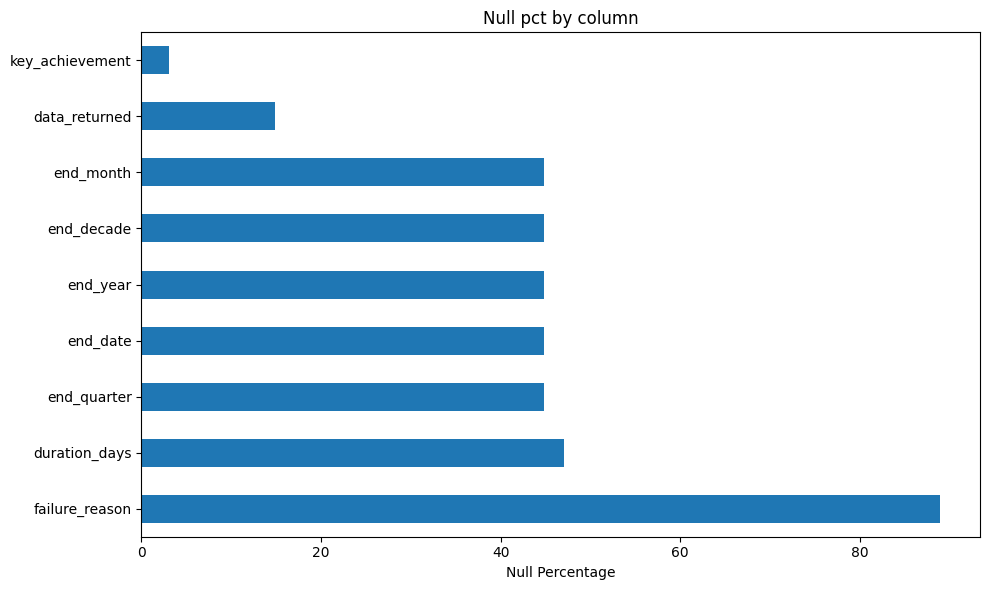

In [27]:
fig, ax = plt.subplots(figsize=(10,6))
null_summary['null_pct'].plot(kind = 'barh', ax=ax)
ax.set_title('Null pct by column')
ax.set_xlabel('Null Percentage')
fig.tight_layout()
plt.show()

In [28]:
cat_cols = ["status", "mission_phase", "crew_type", "agency_type",
            "program_type", "mission_category", "data_returned"]

for col in cat_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False))


--- status ---
status
Success            4314
Ongoing            3144
Upcoming           1560
Failed              909
Partial Success     573
Name: count, dtype: int64

--- mission_phase ---
mission_phase
Past       6835
Ongoing    2105
Future     1560
Name: count, dtype: int64

--- crew_type ---
crew_type
Uncrewed    7863
Crewed      2637
Name: count, dtype: int64

--- agency_type ---
agency_type
Government    8689
Private       1811
Name: count, dtype: int64

--- program_type ---
program_type
Robotic              1554
Satellite            1537
Commercial           1511
Telescope            1485
Human Spaceflight    1485
Sounding Rocket      1481
Technology Demo      1447
Name: count, dtype: int64

--- mission_category ---
mission_category
Mercury                    597
Deep Space                 582
SmallSat                   579
Saturn                     575
Moon                       571
Mars                       564
Communication Satellite    563
Telescope                  559


In [29]:
df['cost_usd_million'] = pd.to_numeric(df['cost_usd_million'], errors='coerce')
df['duration_days'] = pd.to_numeric(df['duration_days'], errors='coerce')

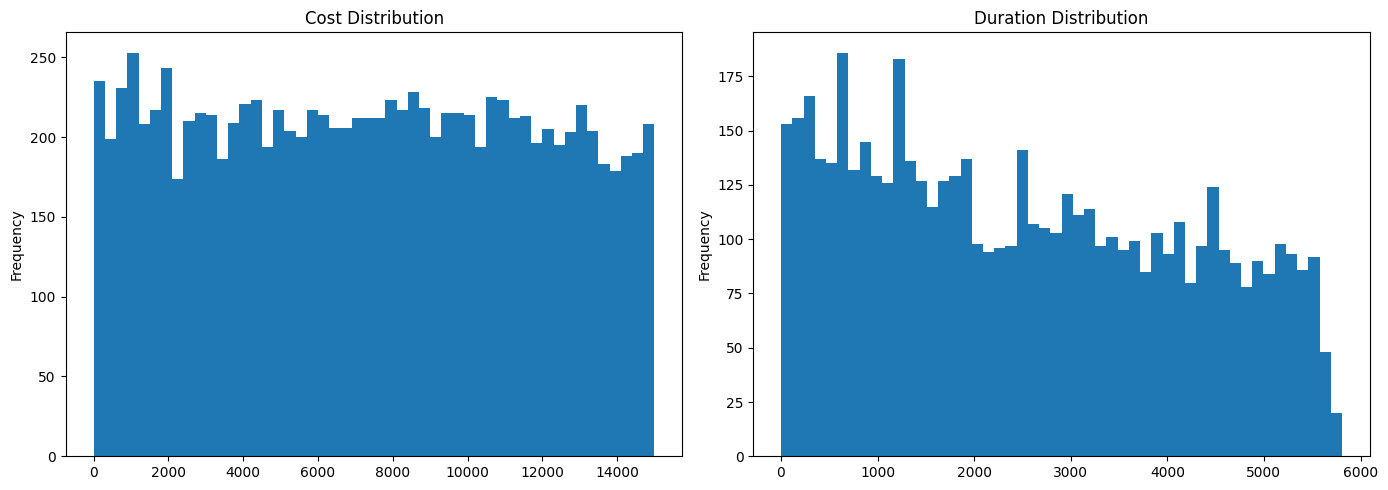

In [30]:
fig,axes = plt.subplots(1,2, figsize=(14,5))
df['cost_usd_million'].plot(kind='hist', bins=50, ax=axes[0])
axes[0].set_title('Cost Distribution')
df['duration_days'].plot(kind='hist', bins=50, ax=axes[1])
axes[1].set_title('Duration Distribution')
plt.tight_layout()
plt.show()

In [34]:
df[df['end_date'].notna() & (df['end_date'] < df['launch_date'])]

,mission_id,mission_name,program_type,mission_category,sub_category,destination,status,mission_phase,crew_type,data_returned,...,launch_decade,end_date,end_year,end_quarter,end_month,end_decade,objective,key_achievement,mission_outcome_detail,reference_url
84,SP-05231,SpaceX Telescope Mission 5231,Human Spaceflight,Telescope,Optical,Telescope,Failed,Past,Uncrewed,Yes,...,1950s,1957-07-23,1957.0,3.0,7.0,1950s,Heliosphere boundary exploration,Communication failure post-separation,Landed successfully within target zone,https://www.spacex.com/missions/spacex-telesco...
181,CN-02601,CNSA Saturn Mission 2601,Technology Demo,Saturn,Probe,Saturn,Partial Success,Past,Uncrewed,Partial,...,1950s,1958-03-31,1958.0,1.0,3.0,1950s,Next-generation communication satellite deploy...,First crewed landing at destination,Failed to achieve orbit due to launch vehicle ...,http://www.cnsa.gov.cn/mission/cnsa-saturn-mis...
273,BL-10163,Blue Origin Moon Mission 10163,Technology Demo,Moon,Flyby,Moon,Success,Past,Crewed,Yes,...,1950s,1959-03-18,1959.0,1.0,3.0,1950s,Earth observation for disaster management,Exceeded planned science return by 3x,Historic first for agency and country,https://www.blueorigin.com/missions/blue-origi...
350,DL-08878,DLR Communication Satellite Mission 8878,Robotic,Communication Satellite,Geostationary,Communication Satellite,Failed,Past,Uncrewed,No,...,1960s,1960-01-28,1960.0,1.0,1.0,1960s,Solar wind and coronal mass ejection monitoring,Launch vehicle upper stage malfunction,Broke distance record for agency,https://www.dlr.de/mission/dlr-communication-s...
439,CS-05729,CSA Sun/Solar Mission 5729,Telescope,Sun/Solar,Solar Observer,Sun/Solar,Success,Past,Crewed,Yes,...,1960s,1961-04-03,1961.0,2.0,4.0,1960s,Asteroid composition and deflection study,Planned - objectives to be confirmed post-launch,Planned - objectives to be confirmed post-launch,https://www.asc-csa.gc.ca/mission/csa-sun/sola...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7677,SP-05299,SpaceX Crewed Spaceflight Mission 5299,Commercial,Crewed Spaceflight,Moon Mission,Crewed Spaceflight,Success,Past,Uncrewed,Partial,...,2020s,2022-06-26,2022.0,2.0,6.0,2020s,Heliosphere boundary exploration,Failed to achieve orbit due to launch vehicle ...,Mission ongoing - data collection in progress,https://www.spacex.com/missions/spacex-crewed-...
7682,JA-09428,JAXA Saturn Mission 9428,Robotic,Saturn,Orbiter,Saturn,Success,Past,Uncrewed,No,...,2020s,2022-04-03,2022.0,2.0,4.0,2020s,High-resolution Earth surface mapping,Confirmed presence of subsurface water,Planned - objectives to be confirmed post-launch,https://www.jaxa.jp/missions/jaxa-saturn-missi...
7683,SP-03185,SpaceX Moon Mission 3185,Commercial,Moon,Flyby,Moon,Failed,Past,Crewed,Partial,...,2020s,2022-08-06,2022.0,3.0,8.0,2020s,High-resolution Earth surface mapping,Launch vehicle upper stage malfunction,Achieved orbit insertion on first attempt,https://www.spacex.com/missions/spacex-moon-mi...
7686,SP-06792,SpaceX CubeSat Mission 6792,Human Spaceflight,CubeSat,16U CubeSat,CubeSat,Success,Past,Crewed,No,...,2020s,2022-08-22,2022.0,3.0,8.0,2020s,Commercial crew certification flight,Planned - objectives to be confirmed post-launch,Extended mission beyond original timeline,https://www.spacex.com/missions/spacex-cubesat...
